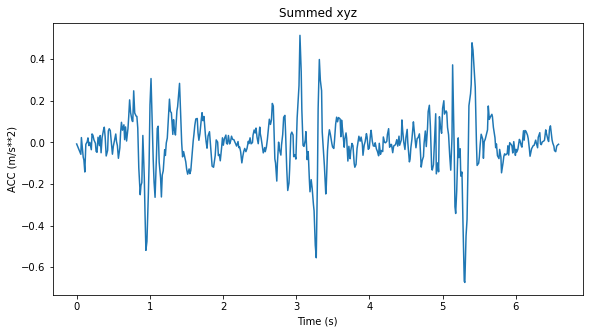

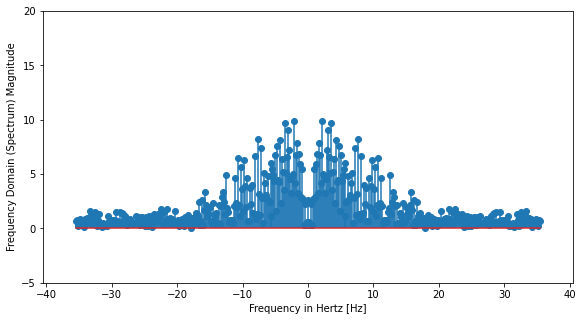

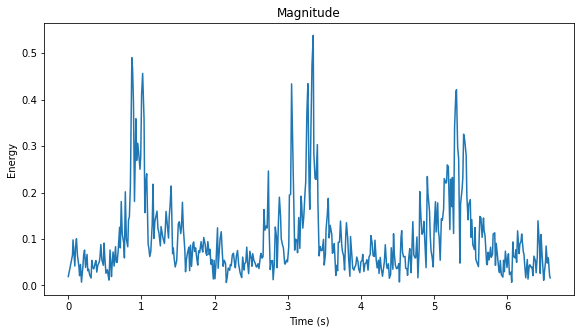

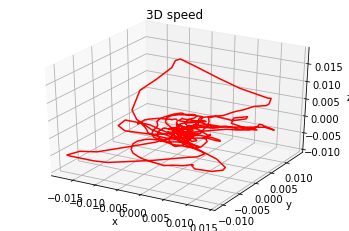

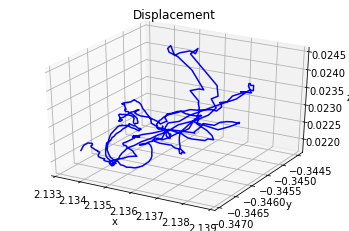

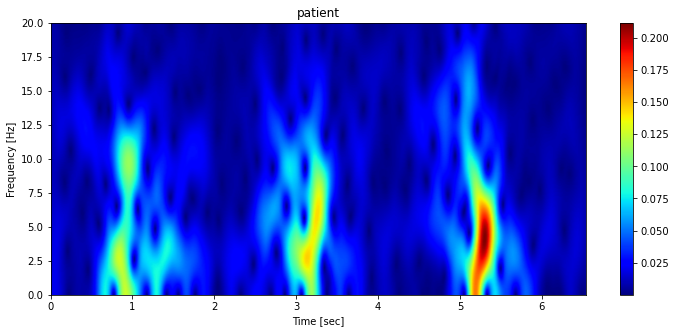

In [8]:
import os
import pandas as pd
import numpy as np
from scipy import signal
from scipy import fftpack
import matplotlib.pyplot as plt
import math
from scipy.fft import fft, ifft
from skimage import util
from mpl_toolkits import mplot3d

def calcSTFT(name, inputSignal, samplingFreq, window='hann', nperseg=256, figsize=(15,5), cmap='jet', ylim_max=None, output=False):
    '''Calculates the STFT for a time series:
        inputSignal: numpy array for the signal (it also works for Pandas.Series);
        samplingFreq: the sampling frequency;
        window : str or tuple or array_like, optional
            Desired window to use. If `window` is a string or tuple, it is
            passed to `get_window` to generate the window values, which are
            DFT-even by default. See `get_window` for a list of windows and
            required parameters. If `window` is array_like it will be used
            directly as the window and its length must be nperseg. Defaults
            to a Hann window.
        nperseg : int, optional
            Length of each segment. Defaults to 256.
        figsize: the plot size, set as (6,3) by default;
        cmap: the color map, set as the divergence Red-Yellow-Green by default;
        ylim_max: the max frequency to be shown. By default it's the half sampling frequency;
        output: 'False', as default. If 'True', returns the STFT values.
        
        Outputs (if TRUE):
            f: the frequency values
            t: the time values
            Zxx: the STFT values"'''
    
    ##Calculating STFT
    #f, t, Zxx = signal.stft(inputSignal, samplingFreq, window=window, nperseg=nperseg)
    f, t, Zxx = signal.stft(inputSignal, samplingFreq, window=window, nperseg=nperseg, noverlap=31, nfft=2048)
    
    ##Plotting STFT
    amp = 2 * np.sqrt(2)
    fig = plt.figure(figsize=figsize)
    ### Different methods can be chosen for normalization: PowerNorm; LogNorm; SymLogNorm.
    ### Reference: https://matplotlib.org/tutorials/colors/colormapnorms.html
    spec = plt.pcolormesh(t, f, np.abs(Zxx),cmap=plt.get_cmap(cmap), shading="gouraud")
   
    cbar = plt.colorbar(spec)
    ##Plot adjustments
    plt.title('STFT Spectrogram')
    ax = fig.axes[0]
    #ax.grid(True)
    ax.set_title(name)
    if ylim_max:
        ax.set_ylim(0,ylim_max)
    ax.set_ylabel('Frequency [Hz]')
    ax.set_xlabel('Time [sec]')
    fig.show
    if output:
        return f,t,Zxx
    else:
        return


df=pd.read_csv('/home/~path/sampledata.csv')


t = df.Time_s_


sample_raw = df.sum_xyz
sample_raw_1 = df.magnitude

sample_raw_2_1 = df.Velo_x
sample_raw_2_2 = df.Velo_y
sample_raw_2_3 = df.Velo_z

sample_raw_3_1 = df.Pos_x
sample_raw_3_2 = df.Pos_y
sample_raw_3_3 = df.Pos_z

## Checking the shape of the variable:

plt.figure(figsize= (9.5,5))
plt.plot(t, sample_raw)
plt.title("Summed xyz")
plt.xlabel("Time (s)")
plt.ylabel("ACC (m/s**2)")
#plt.xlim(0, sample_raw.shape[0]/72)
plt.show()

f_s = 71  # Sampling rate, or number of measurements per second
X = fftpack.fft(sample_raw.values)
freqs = fftpack.fftfreq(len(sample_raw)) * f_s
#fig, ax = plt.subplots()
plt.figure(figsize= (9.5,5))
plt.stem(freqs, np.abs(X), use_line_collection= True)
plt.xlabel('Frequency in Hertz [Hz]')
plt.ylabel('Frequency Domain (Spectrum) Magnitude')
plt.xlim(-f_s / 2 - 5, f_s / 2 +5)
plt.ylim(-5, 20)

plt.figure(figsize= (9.5,5))
plt.plot(t, sample_raw_1)
plt.title("Magnitude")
plt.xlabel("Time (s)")
plt.ylabel("Energy")
#plt.xlim(0, sample_raw.shape[0]/72)
plt.show()


fig = plt.figure()
ax = plt.axes(projection='3d')
#Data for a three-dimensional line
zline = sample_raw_2_1
xline = sample_raw_2_2
yline = sample_raw_2_3
ax.plot3D(xline, yline, zline, 'red')
ax.set_title('3D speed')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

fig = plt.figure()
ax = plt.axes(projection='3d')
#Data for a three-dimensional line
zline = sample_raw_3_1
xline = sample_raw_3_2
yline = sample_raw_3_3
ax.plot3D(xline, yline, zline, 'blue')
ax.set_title('Displacement')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')



## Calculating its STFT
calcSTFT("patient",sample_raw, 72, nperseg=2**5, figsize=(12,5), ylim_max=20, cmap='jet')
